# this notebook includes a technique to impute missing values by not filling it with some value present in the column but by labelling the missing or NA values as 'missing' or some other keyword.
usually creating a new category called missing.<br>
the goal resting to represent somehow the missingness in the data <br> to the model by introducing some sort of distinction.
mostly the word 'missing' itself is used to signify missing values as a distinct category.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('housing_dataset.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [6]:
df.tail()

,FireplaceQu,GarageQual,SalePrice
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125
1459,NaN,TA,147500


In [8]:
df.isnull().mean()*100 # observing the % of missing values in each column

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

Text(0, 0.5, 'Number of houses')

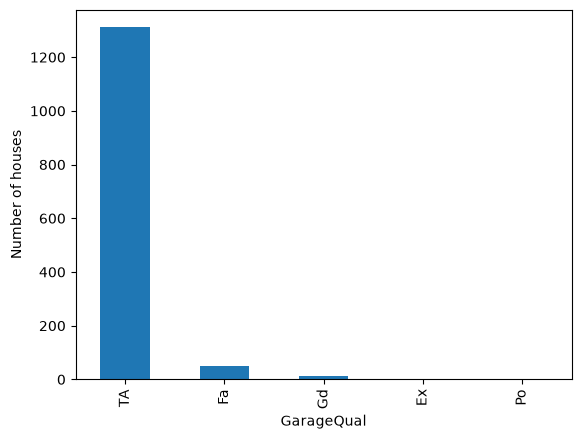

In [9]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

In [10]:
df.fillna({'GarageQual':'Missing'},inplace=True)


,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


Text(0, 0.5, 'Number of houses')

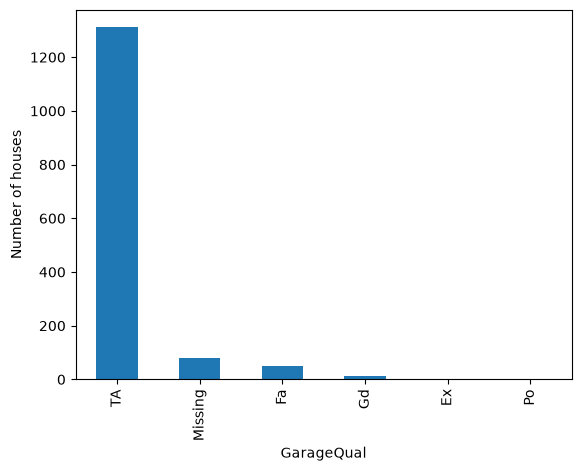

In [11]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('Number of houses')

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2)

In [13]:
from sklearn.impute import SimpleImputer

In [14]:
imputer = SimpleImputer(strategy='constant',fill_value='Missing')

In [16]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_train)

In [17]:
imputer.statistics_

array(['Missing', 'Missing'], dtype=object)